### Keras 를 이용한 손글씨 인식 딥러닝
- TensorFlow 로 작성된 프로그램은 sklearn 보다 무지하게 어렵다.
- Keras 는 테아노(Theano) 와 TensorFlow 를 Wrapping 한 라이브러리

#### 데이터 불러오기

In [3]:
import pandas as pd

train = pd.read_csv('../Data/HandWriting/train_20k.csv', header=None)  # 헤더가 없는데 자동 지정되었으므로 header = None 지정
train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test = pd.read_csv('../Data/HandWriting/test_1k.csv', header=None)  # 헤더가 없는데 자동 지정되었으므로 header = None 지정
test.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### 전처리 (Preprocessing)
##### 결측치 확인

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 119.8 MB


In [11]:
# train 의 결측치
train.isnull().sum().sum()    # 시리즈      #isnull의 sum 이면 각 열 별로 결측치 나옴. 그거의 sum 은 총합

np.int64(0)

In [12]:
test.isnull().sum().sum()

np.int64(0)

 데이터는 비율이 비슷해야 학습을 함. ex_ 0~8은 1000개씩 있는데 9가 2개면 9를 학습 안 함.

#### Target Data 비율 확인

In [14]:
import numpy as np

In [25]:
checkCount = np.unique(train[0], return_counts=True)[1]
np.min(checkCount) / np.max(checkCount)     # 최저/최고 비율이 0.6 은 넘어야 데이터가 쓸모 있음

np.float64(0.7786058746163963)

In [24]:
checkCount1 = train[0].value_counts()
checkCount1.min() / checkCount1.max()       # 이거 써도 되는데 np.unique 가 빨라서 쓰는 거임

0.7786058746163963

> Data의 Target 의 비율이 최소 77% 가 넘는다.

#### train 과 test 를 Target 과 Feature 로 분리하고 정규화하기

In [29]:
# Train 의 Data 와 Target
train_label = train.loc[:,train.columns == 0]
train_data = train.loc[:,train.columns != 0]    / 255.0         # 이미지 최대는 255 이므로

test_label = test.loc[:,test.columns == 0]
test_data = test.loc[:,test.columns != 0]    / 255.0

----
#### Deep Learning Model 만들기

In [32]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [33]:
# 모델 생성하기
model = keras.Sequential()
model.add(Input(shape=(784, )))     # 입력층(Input)
model.add(keras.layers.Dense(100, activation='relu'))       # Dense 값은 아무렇게 가능. 은닉층(여러 개 가능)
model.add(keras.layers.Dense(10, activation='softmax'))     # 다중분류. 출력층

# 손실함수
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 데이터 훈련하기
model.fit(np.array(train_data), np.array(train_label), epochs = 10)     # 현재 pandas 데이터인데 numpy 로 바꿔서 훈련해야 함

Epoch 1/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8855 - loss: 0.4156
Epoch 2/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9428 - loss: 0.2025
Epoch 3/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9601 - loss: 0.1416
Epoch 4/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9692 - loss: 0.1088
Epoch 5/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9769 - loss: 0.0836
Epoch 6/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9808 - loss: 0.0667
Epoch 7/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9848 - loss: 0.0539
Epoch 8/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9898 - loss: 0.0409
Epoch 9/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9920 - loss: 0.0330
Epoch 10/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9939 - loss: 0.0262


#### 테스트 데이터로 평가하기

In [34]:
score = model.evaluate(test_data, test_label)
print("loss = ", score[0])
print("accuracy = ", score[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9670 - loss: 0.1024  
loss =  0.10244710743427277
accuracy =  0.9670329689979553


In [35]:
score = model.evaluate(train_data, train_label)
print("loss = ", score[0])
print("accuracy = ", score[1])

626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 981us/step - accuracy: 0.9965 - loss: 0.0190
loss =  0.01895519345998764
accuracy =  0.9965001940727234


----
#### test_data 로 predict 해보기

In [39]:
pred = model.predict(test_data)
print("test label", test_label[:10])
print("pred max", np.argmax(pred[:10], axis=1))     # argmax : 예측값 중 최대값의 index

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
test label    0
0  7
1  2
2  1
3  0
4  4
5  1
6  4
7  9
8  5
9  9
pred max [7 2 1 0 4 1 4 9 6 9]


In [43]:
# test_data 의 0번 예측값을 확인
print("정답 : ", test_label.loc[0])     # [0] 열 0번지 검색(세로방향), .loc[0] : index = 0 을 검색(가로방향)
print("예측값 : ", np.argmax(pred[0]))

정답 :  0    7
Name: 0, dtype: int64
예측값 :  7


----
#### 사용 : Image 만들기

In [44]:
from PIL import Image

In [46]:
# train_data 크기
train.shape

(20001, 785)

In [47]:
# 0번의 정답을 제외한 데이터
train1 = train.loc[:, train.columns != 0]
train1.shape

(20001, 784)

In [66]:
# train1 데이터의 50번째로 이미지 만들기
abc = np.array(train1.iloc[50]).reshape(28, 28)
abc.shape

(28, 28)

In [69]:
# Image 만들기
image = Image.fromarray((abc).astype(np.uint8))     # (abc).astype 가 아니라 abe.astype 라고 써도 되지만 (a+b).astype 로 묶을 때도 있기 때문에 괄호 쓰면 좋음
image

In [ ]:
# image 저장하기
image.save("../Data/HandWriting/mnist_test_3.jpg", "JPEG")      # jpg 는 JPEG 라고 타입 정해줘야 함.

----
#### 이미지를 불러서 Predict 해보기

In [52]:
# Image 불러오기
img = Image.open("../Data/HandWriting/mnist_test_3.jpg")
img

In [53]:
import matplotlib.pyplot as plt

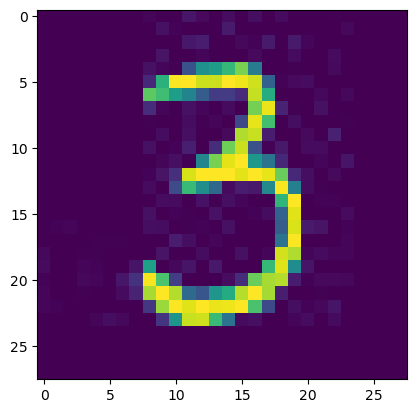

In [54]:
plt.imshow(img)
plt.show()

In [56]:
# Image 를 numpy 배열로 변경하고 정규화 하기
imgArray = np.array(img)    / 255.0
imgArray.shape

(28, 28)

In [57]:
# image 를 1차원 배열로 변경
imgArray2 = imgArray.reshape(-1)
imgArray2.shape

(784,)

In [58]:
imgArray3 = imgArray2.tolist()
imgArray3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.0,
 0.058823529411764705,
 0.023529411764705882,
 0.0,
 0.03137254901960784,
 0.0,
 0.03529411764705882,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.0,
 0.00392156862745098,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.043137254901960784,
 0.00784313725490196,
 0.0,
 0.0,
 0.0,
 0.07058823529411765,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0196078431372549,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.06274509803921569,
 0.07450980392156863,
 0.0,
 0.0,
 0.0196078431372549,
 0.00784313725490196,
 0.07058823529411765,
 0.0,
 0.07058823529411765,
 0.011764705882352941,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.050980392156862744,
 0.0,
 0.0,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.023529411764705882,
 0.0,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.02

In [61]:
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T         # 이전에 fit(학습)과 행 / 열 이 반대이기 때문에 이를 바꿔주기 위해 '.T' 로 바꿔줌
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011765,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
print("예측값 : ", np.argmax(model.predict(dfArray), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
예측값 :  [3]


In [64]:
model.predict(dfArray)      # 이 결과값들은 0 ~ 9 까지일 확률인 거. 3이 9.99x10^(-1) 로 가장 높게 예측되므로 3을 출력한 거임.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


array([[3.3452989e-07, 1.1855264e-04, 3.9300239e-06, 9.9978453e-01,
        7.1363653e-09, 3.6604943e-05, 1.0384697e-08, 8.8577670e-09,
        4.3993614e-06, 5.1615531e-05]], dtype=float32)

----
### train1 데이터의 150번째로 이미지 만들기

In [86]:
abc150 = np.array(train1.iloc[150]).reshape(28, 28)
abc150.shape

(28, 28)

In [74]:
# Image 만들기
image150 = Image.fromarray((abc150).astype(np.uint8))
image150

In [77]:
# image 저장하기
image150.save("../Data/HandWriting/mnist_test_random.jpg", "JPEG")      # jpg 는 JPEG 라고 타입 정해줘야 함.

In [78]:
# Image 불러오기
img150 = Image.open("../Data/HandWriting/mnist_test_random.jpg")
img150

In [79]:
# Image 를 numpy 배열로 변경하고 정규화 하기
imgArray150 = np.array(img150)    / 255.0
imgArray150.shape

(28, 28)

In [80]:
# image 를 1차원 배열로 변경
imgArray150_2 = imgArray150.reshape(-1)
imgArray150_2.shape

(784,)

In [81]:
imgArray150_3 = imgArray150_2.tolist()
imgArray150_3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.00392156862745098,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.058823529411764705,
 0.0,
 0.01568627450980392,
 0.0392156862745098,
 0.0,
 0.0,
 0.00784313725490196,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00784313725490196,
 0.01568627450980392,
 0.0,
 0.0,
 0.01568627450980392,
 0.00784313725490196,
 0.0,
 0.023529411764705882,
 0.0,
 0.00784313725490196,
 0.00784313725490196,
 0.027450980392156862,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00784313725490196,
 0.0196078431372549,
 0.00784313725490196,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00392156862745098,
 0.01568627450980392,
 0.00392156862745098,
 0.0,
 0.011764705882352941

In [83]:
dfArray150 = pd.DataFrame(imgArray150_3)
dfArray150 = dfArray150.T         # 이전에 fit(학습)과 행 / 열 이 반대이기 때문에 이를 바꿔주기 위해 '.T' 로 바꿔줌
dfArray150

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.027451,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [84]:
print("예측값 : ", np.argmax(model.predict(dfArray150), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
예측값 :  [4]


In [85]:
# 확률 확인
model.predict(dfArray150)      # 이 결과값들은 0 ~ 9 까지일 확률인 거. 3이 9.99x10^(-1) 로 가장 높게 예측되므로 3을 출력한 거임.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


array([[1.3273195e-05, 1.7594208e-05, 1.3764431e-03, 1.5236354e-03,
        9.9522310e-01, 1.8519708e-07, 1.4970618e-03, 3.3503104e-04,
        3.5936952e-07, 1.3384521e-05]], dtype=float32)

----
#### 딥러닝 구성
##### 딥러닝 신경망의 흐름

##### 1. 입력층(Input Layer)
- 입력 데이터를 받는 층. 데이터는 보통 숫자로 변환된 상태로 들어옴.
- 입력층은 데이터의 특징이나 변수를 신경망에 전달한다.

##### 2. 은닉층(Hidden Layer)
- 입력층에서 받은 데이터를 처리하는 중간 단계. 하나 이상의 은닉층이 있을 수 있음.
- 각 은닉층에서는 활성화 함수(Activation Function) 가 적용됨. 각 노드에서 계산된 값을 비선형적으로 변환하여(확률) 다음 층으로 전달함.
- 대표적인 활성화 함수로는 ReLu, Sigmoid, Adam, Tanh

##### 3. 출력층(Output Layer)
- 은닉층에서 전달된 데이터를 최종적으로 처리하여 결과를 내는 층.
- 분류 문제라면 Softmax 나 Sigmoid 같은 활성화 함수가 사용되어 예측 확률을 계산함.

##### 4. 손실함수(Loss Function)
- 출력층에서 나온 결과와 실제 값(정답)을 비교하여 오류를 계산.
- 손실함수는 예측이 얼마나 잘못 되었는지를 평가. 대표적인 손실함수로는 회귀 문제에 사용되는 MAE, RMSE와 분류 문제에 사용되는 Cross Entropy 가 있음.

##### 5. 최적화 함수(Optimization Function)
- 손실함수에서 계산된 오류를 바탕으로 네트워크의 가중치를 업데이트함. 이를 통해 모델이 더 좋은 예측을 할 수 있도록 학습이 진행.
- 대표적인 최적화 함수는 확률적 경사하강법, Adam 이 있음.
- 최적화 함수는 역전파(BackPropagation) 과정에서 가중치와 편향을 조절하는 역할을 함.

이 과정이 여러 번 반복되면서 신경망은 학습을 통해 점점 더 좋은 결과를 내놓게 된다.